<a href="https://colab.research.google.com/github/venkata18167/CSA6102-DIGITAL-FORENSICS-AND-CYBERCRIME-INVESTIGATION/blob/main/17_Hacking_Attack_Simulation_(Ethical).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Security Logs

       Time            IP          Event               Data
0  10:00:01  192.168.1.10     LOGIN_FAIL              admin
1  10:00:05  192.168.1.10     LOGIN_FAIL              admin
2  10:00:08  192.168.1.10     LOGIN_FAIL              admin
3  10:01:15  192.168.1.15  LOGIN_SUCCESS               user
4  10:02:10  192.168.1.20    WEB_REQUEST             /login
5  10:03:00  192.168.1.25    WEB_REQUEST       /search?id=1
6  10:04:20  192.168.1.30    WEB_REQUEST  /../../etc/passwd
7  10:05:30  192.168.1.35    WEB_REQUEST   /login?user=test

Repeated Login Failure Detection

Suspicious Login Pattern: 192.168.1.10

Directory Traversal Detection

Traversal Detected: 192.168.1.30

SQL Injection Pattern Detection


Weak Password Analysis

123456 --> Weak Password
admin --> Weak Password
Password123 --> Strong Password
welcome --> Weak Password
StrongPass@2025 --> Strong Password

Attack Pattern Report

             IP                   Attack Severity
0  192.168.1.10  Repeated Logi

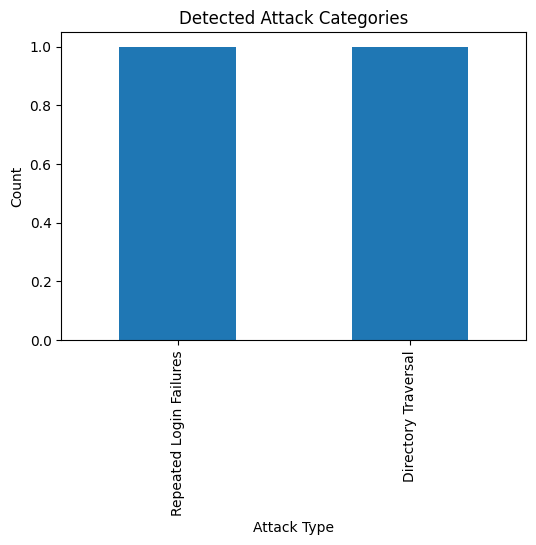

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Experiment Completed Successfully


In [1]:


import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

logs = [
    ["10:00:01", "192.168.1.10", "LOGIN_FAIL", "admin"],
    ["10:00:05", "192.168.1.10", "LOGIN_FAIL", "admin"],
    ["10:00:08", "192.168.1.10", "LOGIN_FAIL", "admin"],
    ["10:01:15", "192.168.1.15", "LOGIN_SUCCESS", "user"],
    ["10:02:10", "192.168.1.20", "WEB_REQUEST", "/login"],
    ["10:03:00", "192.168.1.25", "WEB_REQUEST", "/search?id=1"],
    ["10:04:20", "192.168.1.30", "WEB_REQUEST", "/../../etc/passwd"],
    ["10:05:30", "192.168.1.35", "WEB_REQUEST", "/login?user=test"],
]

df = pd.DataFrame(logs, columns=["Time","IP","Event","Data"])

print("Security Logs\n")
print(df)


failed = df[df["Event"] == "LOGIN_FAIL"]
failed_count = failed.groupby("IP").size().reset_index(name="Failed_Attempts")

attack_logs = []

print("\nRepeated Login Failure Detection\n")

for _, row in failed_count.iterrows():

    if row["Failed_Attempts"] >= 3:

        print("Suspicious Login Pattern:", row["IP"])

        attack_logs.append([
            row["IP"],
            "Repeated Login Failures",
            "Medium"
        ])

print("\nDirectory Traversal Detection\n")

for _, row in df.iterrows():

    if "../" in row["Data"]:

        print("Traversal Detected:", row["IP"])

        attack_logs.append([
            row["IP"],
            "Directory Traversal",
            "High"
        ])

print("\nSQL Injection Pattern Detection\n")

sql_keywords = [
    "union",
    "select",
    "drop",
    "insert",
    "delete",
    "--"
]

for _, row in df.iterrows():

    text = row["Data"].lower()

    found = False

    for keyword in sql_keywords:

        if keyword in text:
            found = True

    if found:

        print("Suspicious SQL Pattern:", row["IP"])

        attack_logs.append([
            row["IP"],
            "SQL Injection Pattern",
            "High"
        ])

passwords = [
    "123456",
    "admin",
    "Password123",
    "welcome",
    "StrongPass@2025"
]

weak = [
    "123456",
    "password",
    "admin",
    "welcome",
    "qwerty"
]

print("\nWeak Password Analysis\n")

for p in passwords:

    if p.lower() in weak:

        print(p, "--> Weak Password")

    else:

        print(p, "--> Strong Password")

attack_df = pd.DataFrame(
    attack_logs,
    columns=["IP","Attack","Severity"]
)

print("\nAttack Pattern Report\n")
print(attack_df)

attack_df.to_csv("attack_pattern_logs.csv", index=False)

report = pd.DataFrame({

    "Vulnerability":[
        "Repeated Login Failures",
        "Directory Traversal",
        "Suspicious SQL Pattern"
    ],

    "Risk":[
        "Medium",
        "High",
        "High"
    ]
})

print("\nVulnerability Classification Report\n")
print(report)

report.to_csv(
    "vulnerability_classification_report.csv",
    index=False
)
rules = [

"Block repeated login failures from same IP",

"Block requests containing ../",

"Inspect requests containing SQL keywords",

"Enable input validation",

"Enable rate limiting"

]

with open("waf_rule_suggestions.txt","w") as f:

    for rule in rules:

        f.write(rule + "\n")

print("\nWAF Rule Suggestions\n")

for r in rules:

    print("-", r)

count = attack_df["Attack"].value_counts()

plt.figure(figsize=(6,4))
count.plot(kind="bar")

plt.title("Detected Attack Categories")
plt.xlabel("Attack Type")
plt.ylabel("Count")

plt.show()

files.download("attack_pattern_logs.csv")
files.download("vulnerability_classification_report.csv")
files.download("waf_rule_suggestions.txt")

print("\nExperiment Completed Successfully")